In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchquad import MonteCarlo
import catboost as cb 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import numpy as np 
import torch 
import torch.nn as nn 
from torchquad import MonteCarlo
import catboost as cb 
import matplotlib.pyplot as plt 

### Вариант 1: Аппроксимация E1 (для малых и больших u)

In [1]:
import torch

def well_function(u):
    # Аппроксимация для E₁(u) (работает для u > 0)
    mask = u < 1.0
    small_u = -torch.log(u) - 0.5772 + u - u**2 / 4  # Аппроксимация для малых u
    large_u = (torch.exp(-u) / u) * (1 - 1/u + 2/u**2)  # Аппроксимация для больших u
    return torch.where(mask, small_u, large_u)

def theis_model(t, T, S, Q, r):
    u = (r**2 * S) / (4 * T * t)
    return (Q / (4 * torch.pi * T)) * well_function(u)

## Вариант 2: Численное интегрирование.

In [5]:
def well_function(u, num_samples=1000):
    integrator = MonteCarlo()
    def integrand(tau):
        return torch.exp(-tau) / tau
    result = torch.zeros_like(u)
    for i in range(len(u)):
        result[i] = integrator.integrate(integrand, dim=1, N=num_samples, integration_domain=[[u[i].item(), 100.0]])
    return result

In [6]:
import torch.optim as optim

# Данные (переведите в тензоры PyTorch)
t_data = torch.tensor([1.0, 10.0, 100.0, 1000.0], dtype=torch.float32)
s_data = torch.tensor([0.5, 1.2, 2.0, 2.8], dtype=torch.float32)

# Известные параметры
Q = 1.0
r = 10.0

# Инициализация оптимизируемых параметров (T и S)
T = torch.nn.Parameter(torch.tensor(1e-3, dtype=torch.float32))  # Начальное guess
S = torch.nn.Parameter(torch.tensor(1e-4, dtype=torch.float32))

# Оптимизатор
optimizer = optim.SGD([T, S], lr=1e-5)  # Или Adam

# Цикл обучения
for epoch in range(1000):
    optimizer.zero_grad()
    s_pred = theis_model(t_data, T, S, Q, r)
    loss = torch.mean((s_pred - s_data)**2)  # MSE
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, T: {T.item():.4e}, S: {S.item():.4e}")

print(f"Оптимизированные параметры: T = {T.item():.4e} м²/с, S = {S.item():.4e}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


Epoch 0, Loss: 12601.8057, T: 2.5549e+02, S: 1.0000e-04
Epoch 100, Loss: 3.3793, T: 2.5549e+02, S: 1.0000e-04
Epoch 200, Loss: 3.3792, T: 2.5549e+02, S: 1.0000e-04
Epoch 300, Loss: 3.3539, T: 2.5549e+02, S: 1.0000e-04
Epoch 400, Loss: 3.3743, T: 2.5549e+02, S: 1.0000e-04
Epoch 500, Loss: 3.3796, T: 2.5549e+02, S: 1.0000e-04
Epoch 600, Loss: 3.3372, T: 2.5549e+02, S: 1.0000e-04
Epoch 700, Loss: 3.3701, T: 2.5549e+02, S: 1.0000e-04
Epoch 800, Loss: 3.3720, T: 2.5549e+02, S: 1.0000e-04
Epoch 900, Loss: 3.3798, T: 2.5549e+02, S: 1.0000e-04
Оптимизированные параметры: T = 2.5549e+02 м²/с, S = 1.0000e-04


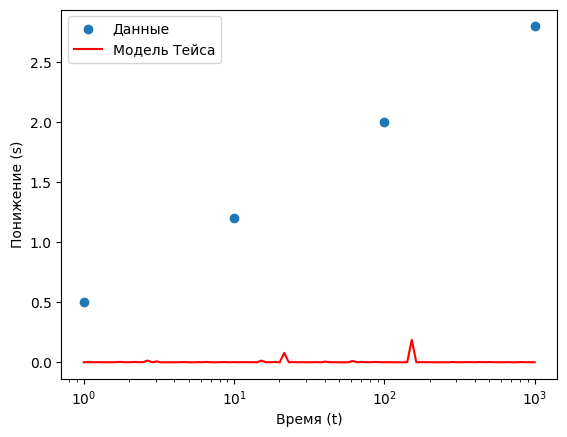

In [7]:
import matplotlib.pyplot as plt

# Предсказанные значения
t_test = torch.logspace(0, 3, 100)  # Тестовые точки
s_test = theis_model(t_test, T, S, Q, r)

# График
plt.scatter(t_data, s_data, label="Данные")
plt.plot(t_test, s_test.detach().numpy(), 'r-', label="Модель Тейса")
plt.xscale('log')
plt.xlabel("Время (t)")
plt.ylabel("Понижение (s)")
plt.legend()
plt.show()